### **Sentiment Analysis with BERT**  

This notebook focuses on training and evaluating a BERT-based model for sentiment analysis using three datasets: Amazon Books Reviews, Sentiment140, and Yelp Reviews. The objective is to leverage Transformer-based architectures, specifically DistilBERT, to enhance sentiment classification performance.  

The workflow includes data loading, tokenization, model training, hyperparameter optimization, and evaluation. Additionally, augmented datasets are used to test the model’s robustness against noisy inputs. The notebook implements DistilBERT, a lighter variant of BERT, to balance performance and computational efficiency.  

#### **1. BERT Model - Amazon Books Reviews**  
- **1.1. Loading Data**  
- **1.2. Data Preprocessing**  
- **1.3. Model Training**  
- **1.6. Searching for Best Model Parameters**  
- **1.7. Model Evaluation on Test Data**  
- **1.8. Model Evaluation on Augmented Data**  
- **1.9. Save Model**  

#### **2. BERT Model - Sentiment140**  
- **2.1. Loading Data**  
- **2.2. Data Preprocessing**  
- **2.3. Model Training**  
- **2.6. Searching for Best Model Parameters**  
- **2.7. Model Evaluation on Test Data**  
- **2.8. Model Evaluation on Augmented Data**  
- **2.9. Save Model**  

#### **3. BERT Model - Yelp Reviews**  
- **3.1. Loading Data**  
- **3.2. Data Preprocessing**  
- **3.3. Model Training**  
- **3.6. Searching for Best Model Parameters**  
- **3.7. Model Evaluation on Test Data**  
- **3.8. Model Evaluation on Augmented Data**  
- **3.9. Save Model**  


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import tensorflow as tf
from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.callbacks import EarlyStopping

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
import sys

src_path = os.path.abspath('../src')
sys.path.append(src_path)

from preprocessing.data_utils import DataUtils
from models import train_bert

In [3]:
# check GPU availability
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [19]:
def tokenize(df, model_name, max_length=128, batch_size=16):
    # remove rows where 'Review' is NaN or empty
    df = df.dropna(subset=['Review']).copy()
    df = df[df['Review'].str.strip() != '']

    # initialize tokenizer
    tokenizer = DistilBertTokenizer.from_pretrained(model_name)
    
    # convert polarity to integers if it's not already
    if not np.issubdtype(df['Polarity'].dtype, np.integer):
        try:
            df['Polarity'] = df['Polarity'].astype(int)
        except ValueError:
            raise ValueError("'Polarity' column must contain integer values representing sentiment.")

    # tokenize reviews
    inputs = tokenizer(
        df['Review'].tolist(),
        max_length=max_length,
        padding=True,
        truncation=True,
        return_tensors='tf'
    )

    # convert polarity labels to TensorFlow tensor
    labels = tf.convert_to_tensor(df['Polarity'].values, dtype=tf.int32)

    return tf.data.Dataset.from_tensor_slices(({
        'input_ids': inputs['input_ids'],
        'attention_mask': inputs['attention_mask']
    }, labels)).batch(batch_size)

# 1. BERT Model - Amazon Books Reviews

## 1.1. Loading Data

In [4]:
# load the dataset
amazon_file = '../data/preprocessed/amazon.csv'
amazon_df = pd.read_csv(amazon_file, engine='python', encoding="ISO-8859-1")

In [6]:
# preview the data
amazon_df.head()

,Polarity,Review
0,0,As a Man Stinketh
1,1,MY FAVORITE!!
2,1,Epic novel
3,1,Very good source for Web Applications Development
4,1,Great fantasy


In [7]:
train_val_amazon_df, test_amazon_df = train_test_split(
    amazon_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=amazon_df['Polarity']
)

In [8]:
train_amazon_df, val_amazon_df = train_test_split(
    train_val_amazon_df, 
    test_size=0.1765, # 15% of the original data
    random_state=42, 
    stratify=train_val_amazon_df['Polarity']
)

In [9]:
DataUtils.count_reviews_by_polarity(train_amazon_df)

Number of reviews with Polarity=1: 49382
Number of reviews with Polarity=0: 49382


In [10]:
DataUtils.count_reviews_by_polarity(val_amazon_df)

Number of reviews with Polarity=1: 10585
Number of reviews with Polarity=0: 10584


In [11]:
DataUtils.count_reviews_by_polarity(test_amazon_df)

Number of reviews with Polarity=1: 10582
Number of reviews with Polarity=0: 10583


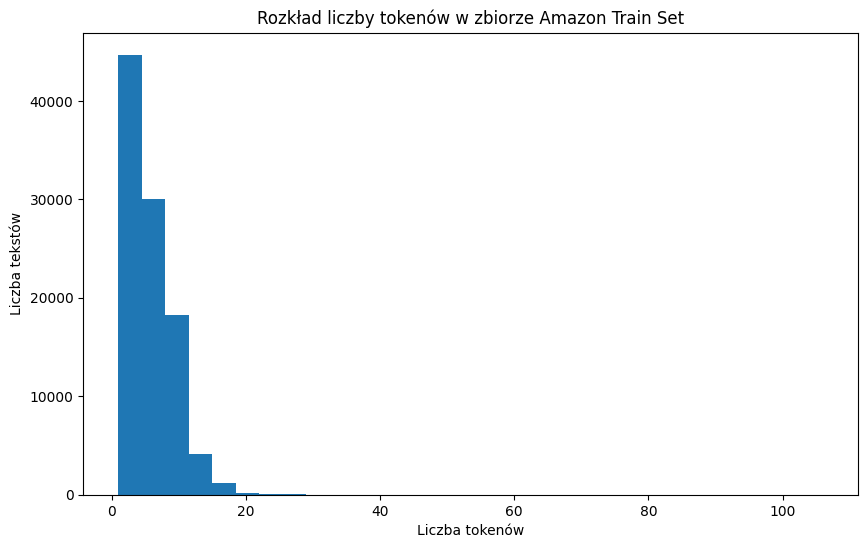

In [12]:
DataUtils.plot_token_distribution(train_amazon_df, "Amazon Train Set")

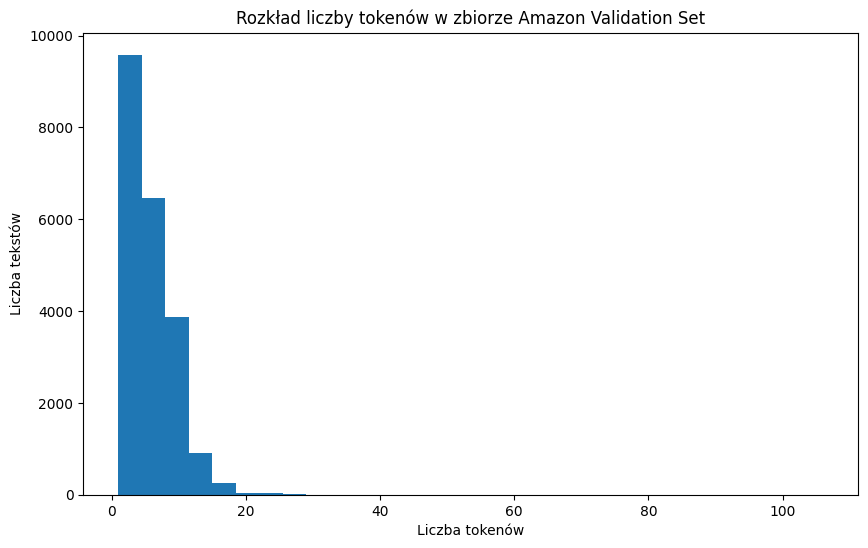

In [13]:
DataUtils.plot_token_distribution(val_amazon_df, "Amazon Validation Set")

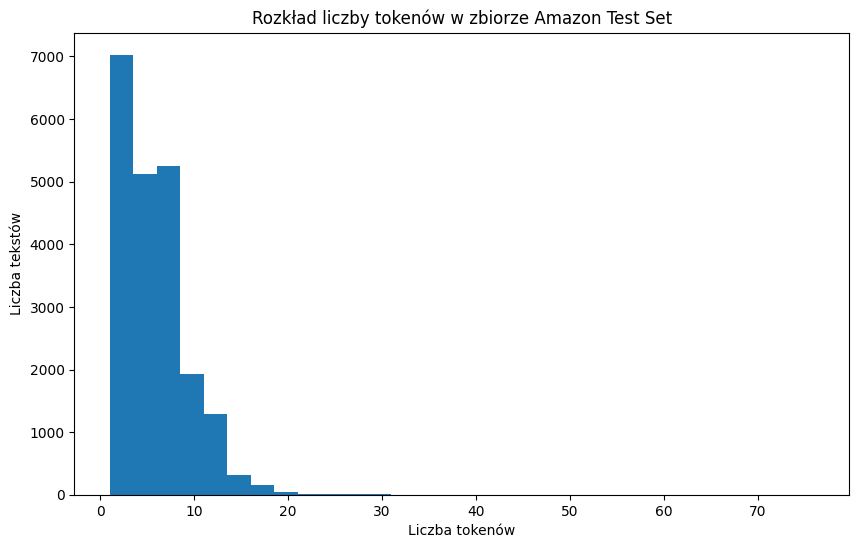

In [14]:
DataUtils.plot_token_distribution(test_amazon_df, "Amazon Test Set")

## 1.2. Data Preprocessing

In [15]:
model_name = 'distilbert-base-uncased' # tokenizer and model name

In [16]:
train_amazon = tokenize(
    df=train_amazon_df, 
    model_name=model_name,
    max_length=32,
    batch_size=16
)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [17]:
val_amazon = tokenize(
    df=val_amazon_df, 
    model_name=model_name,
    max_length=32,
    batch_size=16
)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [18]:
test_amazon = tokenize(
    df=test_amazon_df, 
    model_name=model_name,
    max_length=32,
    batch_size=16
)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


## 1.3. Model Training

In [19]:
# initialize model
model = TFDistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['vocab_projector', 'vocab_transform', 'vocab_layer_norm', 'activation_13']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier', 'classifier', 'dropout_19']
You should probably TRAIN this model on a down-stream task to be able to use i

In [20]:
# compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [21]:
# define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [22]:
# train the model
history = model.fit(
    train_amazon,
    validation_data=val_amazon,
    epochs=4,
    callbacks=[early_stopping]
)

Epoch 1/4
6173/6173 [==============================] - 529s 84ms/step - loss: 0.3319 - accuracy: 0.8501 - val_loss: 0.3010 - val_accuracy: 0.8666
Epoch 2/4
6173/6173 [==============================] - 520s 84ms/step - loss: 0.2360 - accuracy: 0.8993 - val_loss: 0.3222 - val_accuracy: 0.8703
Epoch 3/4
6173/6173 [==============================] - 512s 83ms/step - loss: 0.1598 - accuracy: 0.9370 - val_loss: 0.3628 - val_accuracy: 0.8683


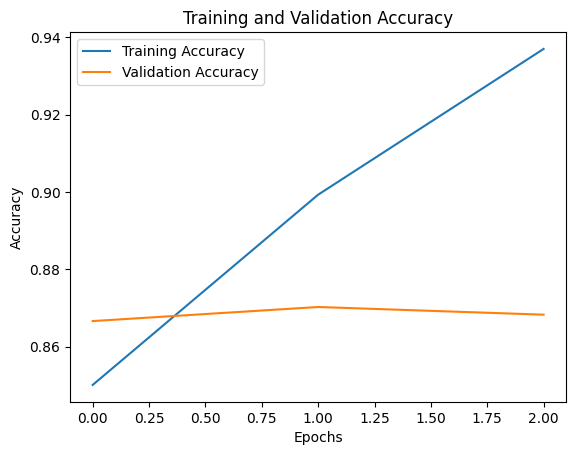

In [23]:
# plot accuracy on training and validation data
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

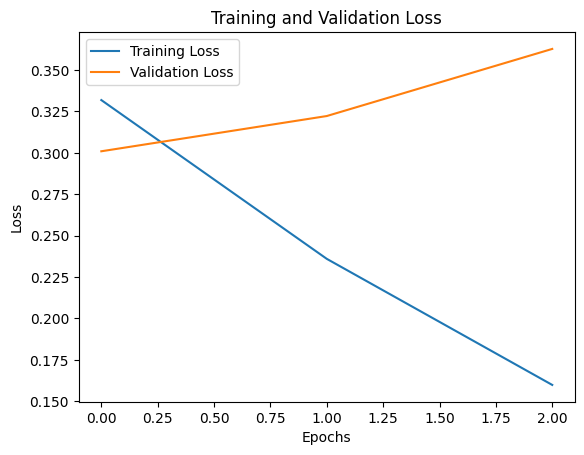

In [24]:
# plot loss on training and validation data
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [25]:
# evaluate the model on the validation set
print("\nValidation Results:")
val_predictions = model.predict(val_amazon)
predicted_labels = np.argmax(val_predictions.logits, axis=1)
true_labels = np.concatenate([y.numpy() for _, y in val_amazon], axis=0)
print(classification_report(true_labels, predicted_labels))


Validation Results:
1324/1324 [==============================] - 39s 28ms/step
              precision    recall  f1-score   support

           0       0.89      0.83      0.86     10584
           1       0.84      0.90      0.87     10585

    accuracy                           0.87     21169
   macro avg       0.87      0.87      0.87     21169
weighted avg       0.87      0.87      0.87     21169



## 1.6. Searching for Best Model Parameters

In [15]:
model_amazon_1, history_amazon_1 = train_bert.fine_tune_bert(train_amazon_df, val_amazon_df, model_name='distilbert-base-uncased', epochs=4, max_length=32, batch_size=16, learning_rate=1e-5)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['vocab_transform', 'activation_13', 'vocab_projector', 'vocab_layer_norm']
- This IS expected if you are initializing TFDistilBertForSequenceClassification f

Epoch 1/4
6173/6173 [==============================] - 530s 85ms/step - loss: 0.3376 - accuracy: 0.8454 - val_loss: 0.3013 - val_accuracy: 0.8666
Epoch 2/4
6173/6173 [==============================] - 511s 83ms/step - loss: 0.2570 - accuracy: 0.8880 - val_loss: 0.3015 - val_accuracy: 0.8708
Epoch 3/4
6173/6173 [==============================] - 506s 82ms/step - loss: 0.1944 - accuracy: 0.9192 - val_loss: 0.3369 - val_accuracy: 0.8708

Validation Results:
1324/1324 [==============================] - 38s 28ms/step
              precision    recall  f1-score   support

           0       0.89      0.84      0.86     10584
           1       0.85      0.90      0.87     10585

    accuracy                           0.87     21169
   macro avg       0.87      0.87      0.87     21169
weighted avg       0.87      0.87      0.87     21169



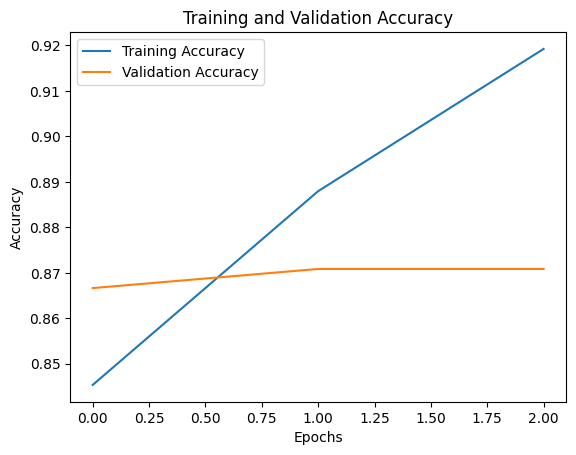

In [16]:
# plot accuracy on training and validation data
plt.plot(history_amazon_1.history['accuracy'], label='Training Accuracy')
plt.plot(history_amazon_1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

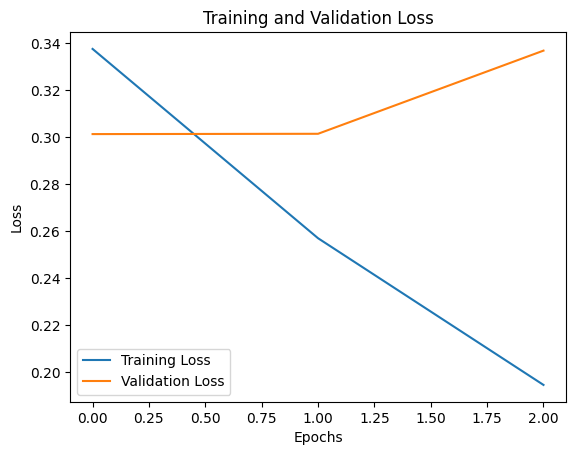

In [17]:
# plot loss on training and validation data
plt.plot(history_amazon_1.history['loss'], label='Training Loss')
plt.plot(history_amazon_1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [18]:
model_amazon_5, history_amazon_5 = train_bert.fine_tune_bert(train_amazon_df, val_amazon_df, model_name='distilbert-base-uncased', epochs=4, max_length=32, batch_size=16, learning_rate=5e-5)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['vocab_transform', 'activation_13', 'vocab_projector', 'vocab_layer_norm']
- This IS expected if you are initializing TFDistilBertForSequenceClassification f

Epoch 1/4
6173/6173 [==============================] - 513s 82ms/step - loss: 0.3386 - accuracy: 0.8461 - val_loss: 0.3068 - val_accuracy: 0.8640
Epoch 2/4
6173/6173 [==============================] - 523s 85ms/step - loss: 0.2389 - accuracy: 0.8991 - val_loss: 0.3677 - val_accuracy: 0.8628
Epoch 3/4
6173/6173 [==============================] - 523s 85ms/step - loss: 0.1621 - accuracy: 0.9373 - val_loss: 0.4145 - val_accuracy: 0.8620

Validation Results:
1324/1324 [==============================] - 38s 28ms/step
              precision    recall  f1-score   support

           0       0.89      0.83      0.86     10584
           1       0.84      0.89      0.87     10585

    accuracy                           0.86     21169
   macro avg       0.87      0.86      0.86     21169
weighted avg       0.87      0.86      0.86     21169



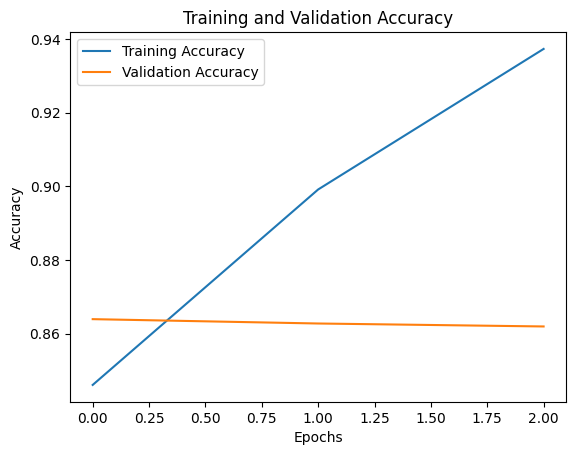

In [19]:
# plot accuracy on training and validation data
plt.plot(history_amazon_5.history['accuracy'], label='Training Accuracy')
plt.plot(history_amazon_5.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

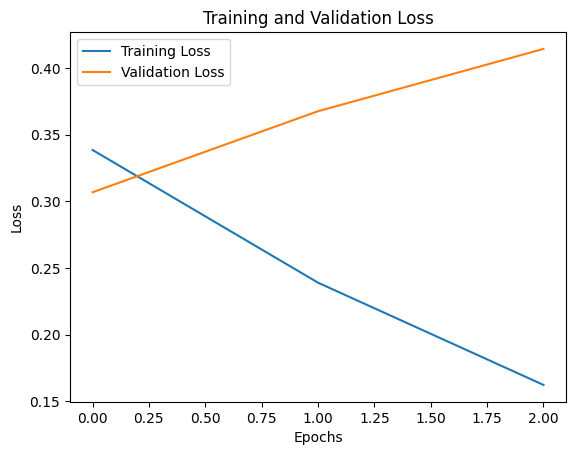

In [20]:
# plot loss on training and validation data
plt.plot(history_amazon_5.history['loss'], label='Training Loss')
plt.plot(history_amazon_5.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

## 1.7. Model Evaluation on Augmented Data

In [26]:
train_bert.evaluate_bert(model, test_amazon)


Evaluating on Test Set...
1323/1323 [==============================] - 37s 28ms/step
              precision    recall  f1-score   support

           0       0.89      0.84      0.86     10583
           1       0.85      0.90      0.87     10581

    accuracy                           0.87     21164
   macro avg       0.87      0.87      0.87     21164
weighted avg       0.87      0.87      0.87     21164



## 1.8. Model Evaluation on Augmented Data

In [27]:
# load the augmented test sets
test_amazon_char_swap_file = '../data/preprocessed/amazon_test_char_swap.csv'
test_amazon_char_swap_df = pd.read_csv(test_amazon_char_swap_file, engine='python', encoding="ISO-8859-1")

test_amazon_embedding_file = '../data/preprocessed/amazon_test_embedding.csv'
test_amazon_embedding_df = pd.read_csv(test_amazon_embedding_file, engine='python', encoding="ISO-8859-1")

test_amazon_eda_file = '../data/preprocessed/amazon_test_eda.csv'
test_amazon_eda_df = pd.read_csv(test_amazon_eda_file, engine='python', encoding="ISO-8859-1")

In [28]:
test_amazon_char_swap = tokenize(
    df=test_amazon_char_swap_df, 
    model_name=model_name,
    max_length=32,
    batch_size=16
)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [29]:
test_amazon_embedding = tokenize(
    df=test_amazon_embedding_df, 
    model_name=model_name,
    max_length=32,
    batch_size=16
)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [30]:
test_amazon_eda = tokenize(
    df=test_amazon_eda_df, 
    model_name=model_name,
    max_length=32,
    batch_size=16
)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [31]:
train_bert.evaluate_bert(model, test_amazon_char_swap)


Evaluating on Test Set...
1323/1323 [==============================] - 38s 28ms/step
              precision    recall  f1-score   support

           0       0.82      0.74      0.78     10583
           1       0.76      0.84      0.80     10581

    accuracy                           0.79     21164
   macro avg       0.79      0.79      0.79     21164
weighted avg       0.79      0.79      0.79     21164



In [32]:
train_bert.evaluate_bert(model, test_amazon_embedding)


Evaluating on Test Set...
1323/1323 [==============================] - 37s 28ms/step
              precision    recall  f1-score   support

           0       0.85      0.80      0.82     10582
           1       0.81      0.85      0.83     10581

    accuracy                           0.83     21163
   macro avg       0.83      0.83      0.83     21163
weighted avg       0.83      0.83      0.83     21163



In [33]:
train_bert.evaluate_bert(model, test_amazon_eda)


Evaluating on Test Set...
1323/1323 [==============================] - 37s 28ms/step
              precision    recall  f1-score   support

           0       0.85      0.80      0.83     10583
           1       0.81      0.86      0.84     10581

    accuracy                           0.83     21164
   macro avg       0.83      0.83      0.83     21164
weighted avg       0.83      0.83      0.83     21164



## 1.9. Save Model

In [34]:
model.save_pretrained("../outputs/models/bert/amazon_bert_model")

# 2. BERT Model - Sentiment140

## 2.1. Loading Data

In [4]:
# load the dataset
sentiment140_file = '../data/preprocessed/sentiment140.csv'
sentiment140_df = pd.read_csv(sentiment140_file, engine='python', encoding="ISO-8859-1")

In [5]:
# preview the data
sentiment140_df.head()

,Polarity,Review
0,1,@Alicia_86 srry u get my tweet?
1,1,@jchiarelli TTS to take text Tweets to the pho...
2,1,Mmmm apple cinnomin oatmeal
3,1,@willwallaceii thanks man. the truth can be fu...
4,1,RAIN The plants and trees are happy ^~^


In [6]:
train_val_sentiment140_df, test_sentiment140_df = train_test_split(
    sentiment140_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=sentiment140_df['Polarity']
)

In [7]:
train_sentiment140_df, val_sentiment140_df = train_test_split(
    train_val_sentiment140_df, 
    test_size=0.1765, # 15% of the original data
    random_state=42, 
    stratify=train_val_sentiment140_df['Polarity']
)

In [8]:
DataUtils.count_reviews_by_polarity(train_sentiment140_df)

Number of reviews with Polarity=1: 111996
Number of reviews with Polarity=0: 111996


In [9]:
DataUtils.count_reviews_by_polarity(val_sentiment140_df)

Number of reviews with Polarity=1: 24004
Number of reviews with Polarity=0: 24004


In [10]:
DataUtils.count_reviews_by_polarity(test_sentiment140_df)

Number of reviews with Polarity=1: 24000
Number of reviews with Polarity=0: 24000


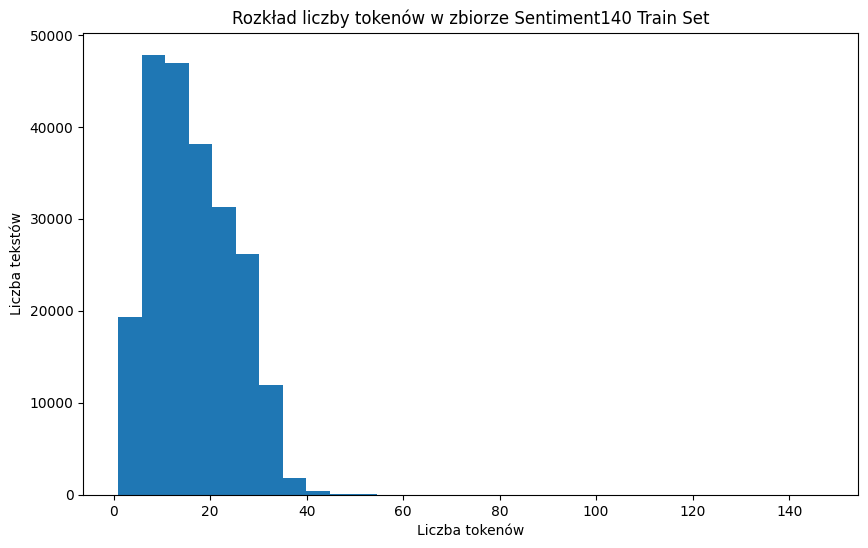

In [11]:
DataUtils.plot_token_distribution(train_sentiment140_df, "Sentiment140 Train Set")

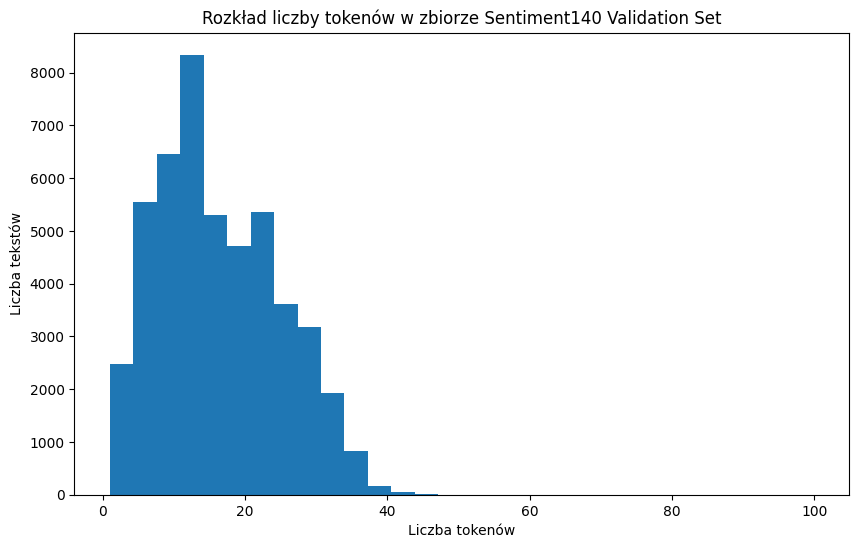

In [12]:
DataUtils.plot_token_distribution(val_sentiment140_df, "Sentiment140 Validation Set")

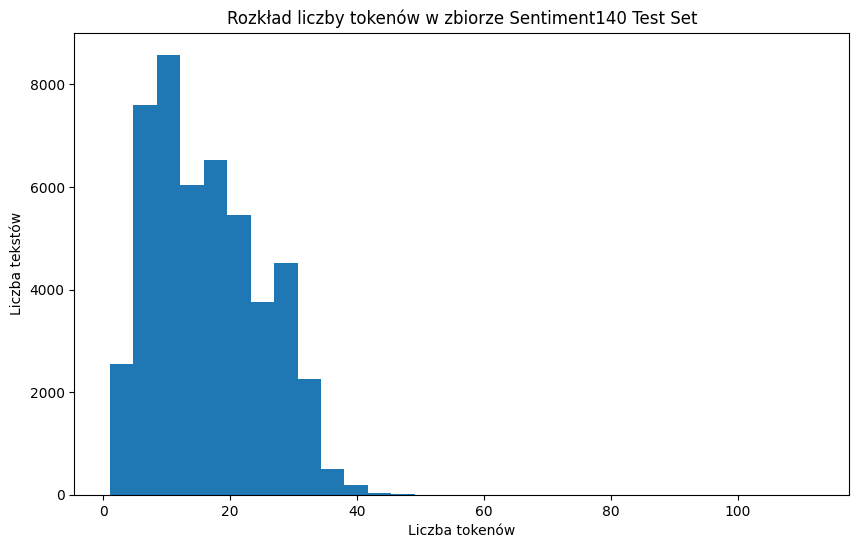

In [13]:
DataUtils.plot_token_distribution(test_sentiment140_df, "Sentiment140 Test Set")

## 2.2. Data Preprocessing

In [21]:
model_name = 'distilbert-base-uncased' # tokenizer and model name

In [46]:
train_sentiment140 = tokenize(
    df=train_sentiment140_df, 
    model_name=model_name,
    max_length=64,
    batch_size=32
)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [47]:
val_sentiment140 = tokenize(
    df=val_sentiment140_df, 
    model_name=model_name,
    max_length=64,
    batch_size=32
)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [22]:
test_sentiment140 = tokenize(
    df=test_sentiment140_df, 
    model_name=model_name,
    max_length=64,
    batch_size=32
)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


## 2.3. Model Training

In [49]:
# initialize model
model = TFDistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['vocab_projector', 'vocab_transform', 'vocab_layer_norm', 'activation_13']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier', 'classifier', 'dropout_39']
You should probably TRAIN this model on a down-stream task to be able to use i

In [50]:
# compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [51]:
# define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [52]:
# train the model
history = model.fit(
    train_sentiment140,
    validation_data=val_sentiment140,
    epochs=4,
    callbacks=[early_stopping]
)

Epoch 1/4
7000/7000 [==============================] - 1138s 162ms/step - loss: 0.3784 - accuracy: 0.8305 - val_loss: 0.3422 - val_accuracy: 0.8502
Epoch 2/4
7000/7000 [==============================] - 1120s 160ms/step - loss: 0.2953 - accuracy: 0.8747 - val_loss: 0.3447 - val_accuracy: 0.8501
Epoch 3/4
7000/7000 [==============================] - 1116s 159ms/step - loss: 0.2160 - accuracy: 0.9129 - val_loss: 0.3861 - val_accuracy: 0.8474


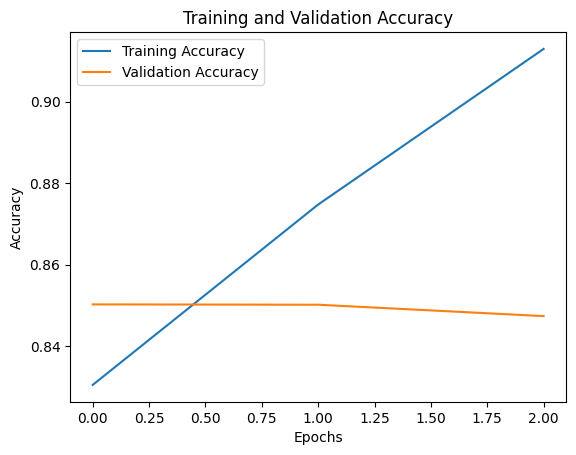

In [53]:
# plot accuracy on training and validation data
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

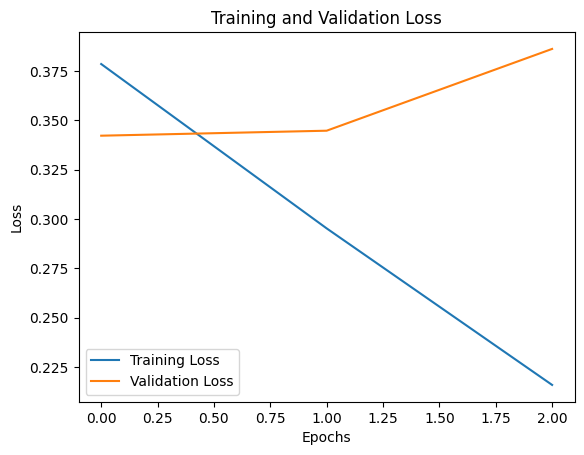

In [54]:
# plot loss on training and validation data
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [55]:
# evaluate the model on the validation set
print("\nValidation Results:")
val_predictions = model.predict(val_sentiment140)
predicted_labels = np.argmax(val_predictions.logits, axis=1)
true_labels = np.concatenate([y.numpy() for _, y in val_sentiment140], axis=0)
print(classification_report(true_labels, predicted_labels))


Validation Results:
1501/1501 [==============================] - 78s 51ms/step
              precision    recall  f1-score   support

           0       0.83      0.87      0.85     24004
           1       0.87      0.83      0.85     24004

    accuracy                           0.85     48008
   macro avg       0.85      0.85      0.85     48008
weighted avg       0.85      0.85      0.85     48008



## 2.6. Searchhing for Best Model Parameters

In [15]:
model_sentiment140_1, history_sentiment140_1 = train_bert.fine_tune_bert(train_sentiment140_df, val_sentiment140_df, model_name='distilbert-base-uncased', epochs=4, max_length=64, batch_size=32, learning_rate=1e-5)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['vocab_transform', 'vocab_projector', 'vocab_layer_norm', 'activation_13']
- This IS expected if you are initializing TFDistilBertForSequenceClassification f

Epoch 1/4
7000/7000 [==============================] - 1957s 279ms/step - loss: 0.3846 - accuracy: 0.8266 - val_loss: 0.3488 - val_accuracy: 0.8450
Epoch 2/4
7000/7000 [==============================] - 1878s 268ms/step - loss: 0.3156 - accuracy: 0.8641 - val_loss: 0.3397 - val_accuracy: 0.8523
Epoch 3/4
7000/7000 [==============================] - 1924s 275ms/step - loss: 0.2620 - accuracy: 0.8904 - val_loss: 0.3609 - val_accuracy: 0.8506
Epoch 4/4
7000/7000 [==============================] - 1808s 258ms/step - loss: 0.2072 - accuracy: 0.9167 - val_loss: 0.4049 - val_accuracy: 0.8459

Validation Results:
1501/1501 [==============================] - 125s 83ms/step
              precision    recall  f1-score   support

           0       0.84      0.88      0.86     24004
           1       0.87      0.83      0.85     24004

    accuracy                           0.85     48008
   macro avg       0.85      0.85      0.85     48008
weighted avg       0.85      0.85      0.85     48008



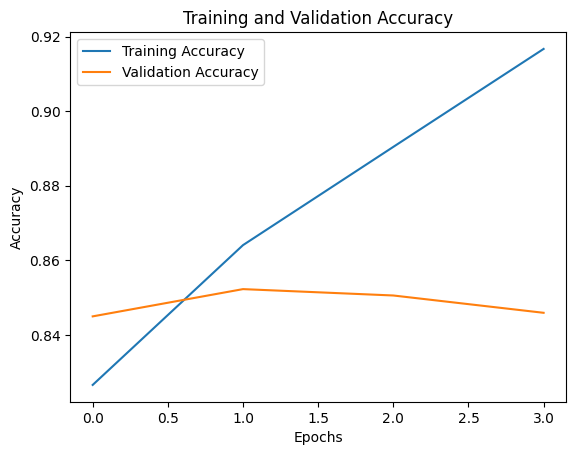

In [16]:
# plot accuracy on training and validation data
plt.plot(history_sentiment140_1.history['accuracy'], label='Training Accuracy')
plt.plot(history_sentiment140_1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

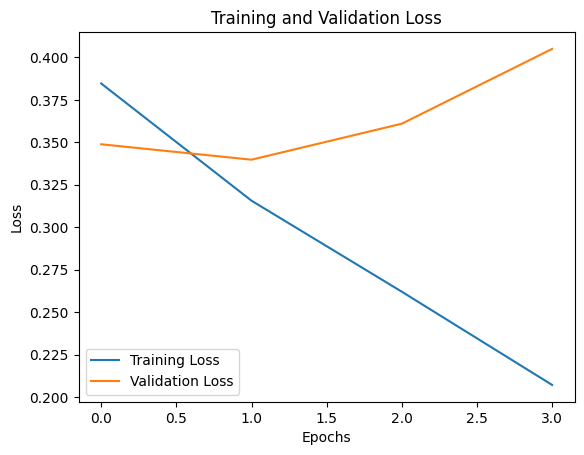

In [17]:
# plot loss on training and validation data
plt.plot(history_sentiment140_1.history['loss'], label='Training Loss')
plt.plot(history_sentiment140_1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [14]:
model_sentiment140_5, history_sentiment140_5 = train_bert.fine_tune_bert(train_sentiment140_df, val_sentiment140_df, model_name='distilbert-base-uncased', epochs=4, max_length=64, batch_size=32, learning_rate=5e-5)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['activation_13', 'vocab_projector', 'vocab_transform', 'vocab_layer_norm']
- This IS expected if you are initializing TFDistilBertForSequenceClassification f

Epoch 1/4
7000/7000 [==============================] - 1916s 273ms/step - loss: 0.3840 - accuracy: 0.8280 - val_loss: 0.3581 - val_accuracy: 0.8387
Epoch 2/4
7000/7000 [==============================] - 1920s 274ms/step - loss: 0.2895 - accuracy: 0.8777 - val_loss: 0.3724 - val_accuracy: 0.8393
Epoch 3/4
7000/7000 [==============================] - 1937s 277ms/step - loss: 0.2040 - accuracy: 0.9187 - val_loss: 0.4231 - val_accuracy: 0.8405

Validation Results:
1501/1501 [==============================] - 137s 91ms/step
              precision    recall  f1-score   support

           0       0.80      0.90      0.85     24004
           1       0.89      0.78      0.83     24004

    accuracy                           0.84     48008
   macro avg       0.84      0.84      0.84     48008
weighted avg       0.84      0.84      0.84     48008



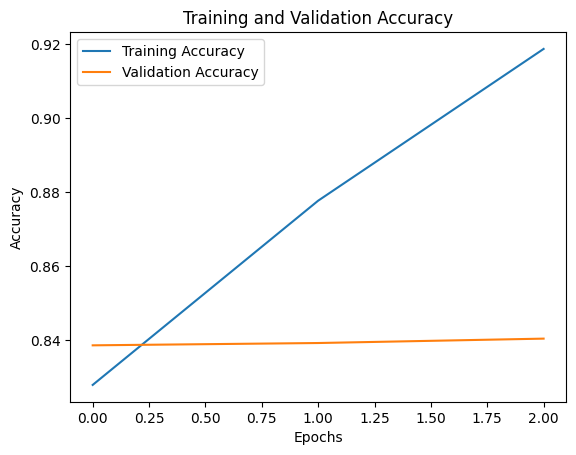

In [15]:
# plot accuracy on training and validation data
plt.plot(history_sentiment140_5.history['accuracy'], label='Training Accuracy')
plt.plot(history_sentiment140_5.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

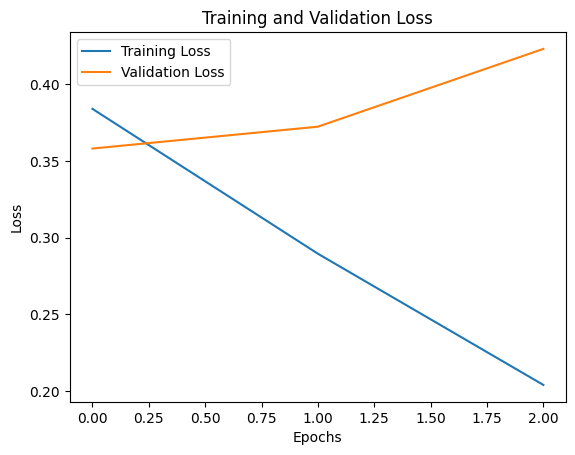

In [16]:
# plot loss on training and validation data
plt.plot(history_sentiment140_5.history['loss'], label='Training Loss')
plt.plot(history_sentiment140_5.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [23]:
train_bert.evaluate_bert(model_sentiment140_5, test_sentiment140)


Evaluating on Test Set...
1500/1500 [==============================] - 137s 92ms/step
              precision    recall  f1-score   support

           0       0.80      0.90      0.85     24000
           1       0.88      0.78      0.83     24000

    accuracy                           0.84     48000
   macro avg       0.84      0.84      0.84     48000
weighted avg       0.84      0.84      0.84     48000



## 2.7. Model Evaluation on Test Data

In [56]:
train_bert.evaluate_bert(model, test_sentiment140)


Evaluating on Test Set...
1500/1500 [==============================] - 77s 51ms/step
              precision    recall  f1-score   support

           0       0.83      0.87      0.85     24000
           1       0.87      0.83      0.85     24000

    accuracy                           0.85     48000
   macro avg       0.85      0.85      0.85     48000
weighted avg       0.85      0.85      0.85     48000



## 2.8. Model Evaluation on Augmented Data

In [57]:
# load the augmented test sets
test_sentiment140_char_swap_file = '../data/preprocessed/sentiment140_test_char_swap.csv'
test_sentiment140_char_swap_df = pd.read_csv(test_sentiment140_char_swap_file, engine='python', encoding="ISO-8859-1")

test_sentiment140_embedding_file = '../data/preprocessed/sentiment140_test_embedding.csv'
test_sentiment140_embedding_df = pd.read_csv(test_sentiment140_embedding_file, engine='python', encoding="ISO-8859-1")

test_sentiment140_eda_file = '../data/preprocessed/sentiment140_test_eda.csv'
test_sentiment140_eda_df = pd.read_csv(test_sentiment140_eda_file, engine='python', encoding="ISO-8859-1")

In [58]:
test_sentiment140_char_swap = tokenize(
    df=test_sentiment140_char_swap_df, 
    model_name=model_name,
    max_length=64,
    batch_size=32
)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [59]:
test_sentiment140_embedding = tokenize(
    df=test_sentiment140_embedding_df, 
    model_name=model_name,
    max_length=64,
    batch_size=32
)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [60]:
test_sentiment140_eda = tokenize(
    df=test_sentiment140_eda_df, 
    model_name=model_name,
    max_length=64,
    batch_size=32
)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [61]:
train_bert.evaluate_bert(model, test_sentiment140_char_swap)


Evaluating on Test Set...
1500/1500 [==============================] - 77s 51ms/step
              precision    recall  f1-score   support

           0       0.81      0.85      0.83     24000
           1       0.84      0.80      0.82     24000

    accuracy                           0.83     48000
   macro avg       0.83      0.83      0.83     48000
weighted avg       0.83      0.83      0.83     48000



In [62]:
train_bert.evaluate_bert(model, test_sentiment140_embedding)


Evaluating on Test Set...
1500/1500 [==============================] - 77s 51ms/step
              precision    recall  f1-score   support

           0       0.82      0.84      0.83     24000
           1       0.84      0.82      0.83     24000

    accuracy                           0.83     48000
   macro avg       0.83      0.83      0.83     48000
weighted avg       0.83      0.83      0.83     48000



In [63]:
train_bert.evaluate_bert(model, test_sentiment140_eda)


Evaluating on Test Set...
1500/1500 [==============================] - 77s 51ms/step
              precision    recall  f1-score   support

           0       0.82      0.84      0.83     24000
           1       0.84      0.82      0.83     24000

    accuracy                           0.83     48000
   macro avg       0.83      0.83      0.83     48000
weighted avg       0.83      0.83      0.83     48000



## 2.9. Save Model

In [64]:
model.save_pretrained("../outputs/models/bert/sentiment140_bert_model")

# 3. BERT Model - Yelp Reviews

## 3.1. Loading Data

In [4]:
# load the dataset
yelp_file = '../data/preprocessed/yelp.csv'
yelp_df = pd.read_csv(yelp_file, engine='python', encoding="ISO-8859-1")

In [5]:
# preview the data
yelp_df.head()

,Polarity,Review
0,0,The food was pretty good but the server was so...
1,0,Horrible manager! She told us we only needed t...
2,1,I Love the Black Bean Burger. So much so I cam...
3,0,Off the beaten path and you can either park yo...
4,1,"Awesome NYC pizza, my second favorite NYC styl..."


In [7]:
train_val_yelp_df, test_yelp_df = train_test_split(
    yelp_df, 
    test_size=0.15, 
    random_state=42, 
    stratify=yelp_df['Polarity']
)

In [8]:
train_yelp_df, val_yelp_df = train_test_split(
    train_val_yelp_df, 
    test_size=0.1765, # 15% of the original data
    random_state=42, 
    stratify=train_val_yelp_df['Polarity']
)

In [9]:
DataUtils.count_reviews_by_polarity(train_yelp_df)

Number of reviews with Polarity=1: 39199
Number of reviews with Polarity=0: 39198


In [10]:
DataUtils.count_reviews_by_polarity(val_yelp_df)

Number of reviews with Polarity=1: 8401
Number of reviews with Polarity=0: 8402


In [11]:
DataUtils.count_reviews_by_polarity(test_yelp_df)

Number of reviews with Polarity=1: 8400
Number of reviews with Polarity=0: 8400


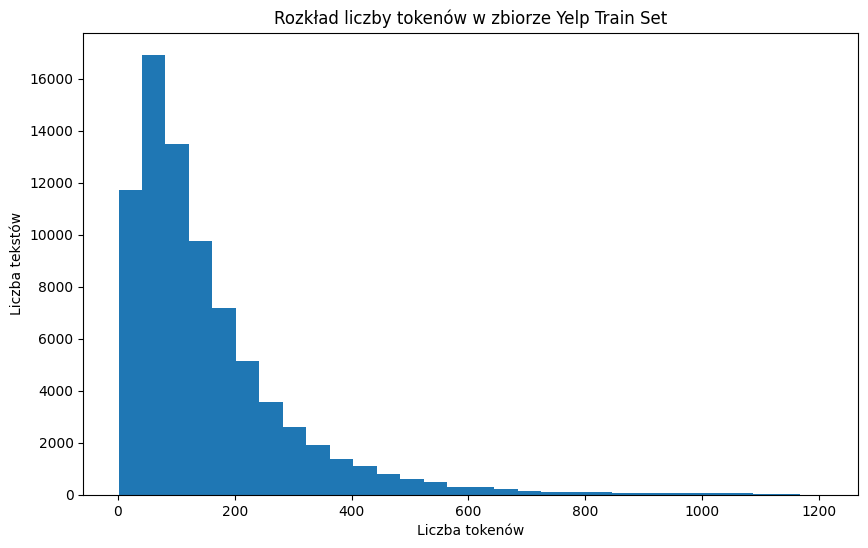

In [12]:
DataUtils.plot_token_distribution(train_yelp_df, "Yelp Train Set")

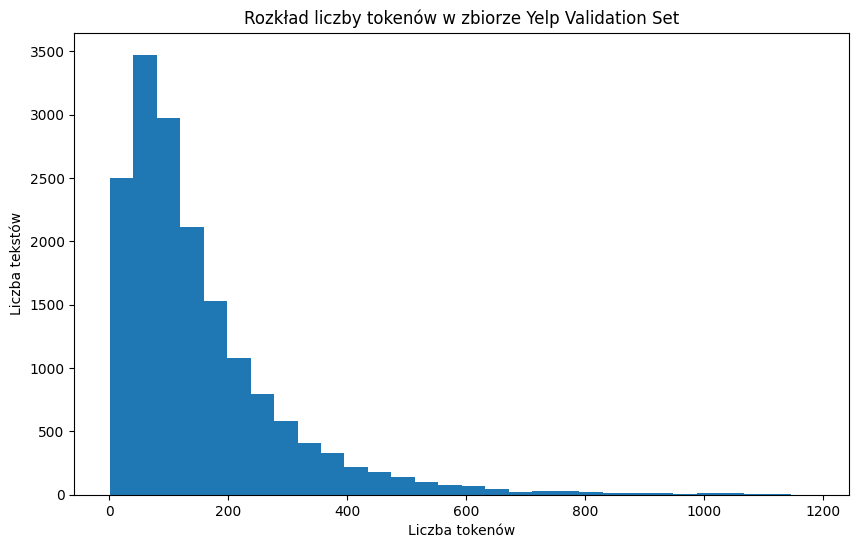

In [13]:
DataUtils.plot_token_distribution(val_yelp_df, "Yelp Validation Set")

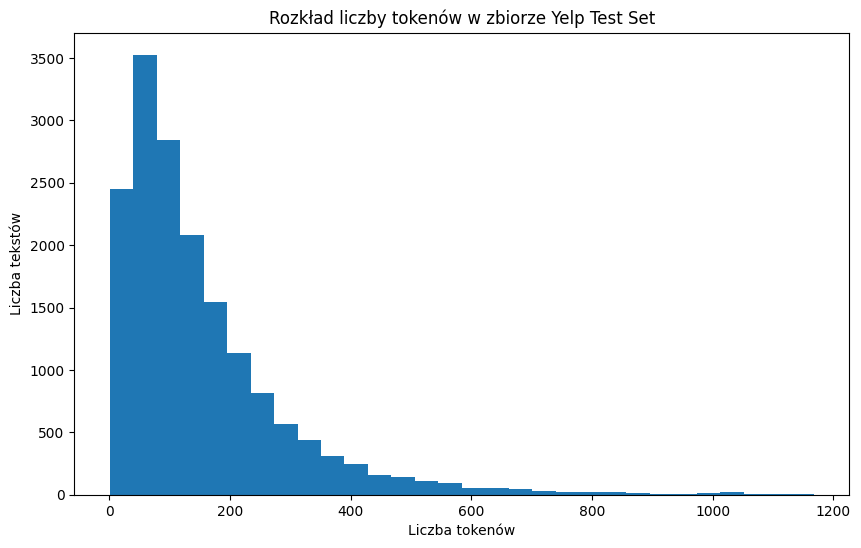

In [14]:
DataUtils.plot_token_distribution(test_yelp_df, "Yelp Test Set")

## 3.2. Data Preprocessing

In [75]:
model_name = 'distilbert-base-uncased' # tokenizer and model name
max_length = 256
batch_size = 8

In [76]:
train_yelp = tokenize(
    df=train_yelp_df, 
    model_name=model_name,
    max_length=max_length,
    batch_size=batch_size
)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [77]:
val_yelp = tokenize(
    df=val_yelp_df, 
    model_name=model_name,
    max_length=max_length,
    batch_size=batch_size
)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [78]:
test_yelp = tokenize(
    df=test_yelp_df, 
    model_name=model_name,
    max_length=max_length,
    batch_size=batch_size
)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


## 3.3. Model Training

In [79]:
# initialize model
model = TFDistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['vocab_projector', 'vocab_transform', 'vocab_layer_norm', 'activation_13']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier', 'dropout_59', 'classifier']
You should probably TRAIN this model on a down-stream task to be able to use i

In [80]:
# compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [81]:
# define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [82]:
# train the model
history = model.fit(
    train_yelp,
    validation_data=val_yelp,
    epochs=4,
    callbacks=[early_stopping]
)

Epoch 1/4
9800/9800 [==============================] - 1696s 172ms/step - loss: 0.1570 - accuracy: 0.9394 - val_loss: 0.1150 - val_accuracy: 0.9538
Epoch 2/4
9800/9800 [==============================] - 1689s 172ms/step - loss: 0.0815 - accuracy: 0.9710 - val_loss: 0.1416 - val_accuracy: 0.9551
Epoch 3/4
9800/9800 [==============================] - 1689s 172ms/step - loss: 0.0429 - accuracy: 0.9849 - val_loss: 0.1690 - val_accuracy: 0.9538


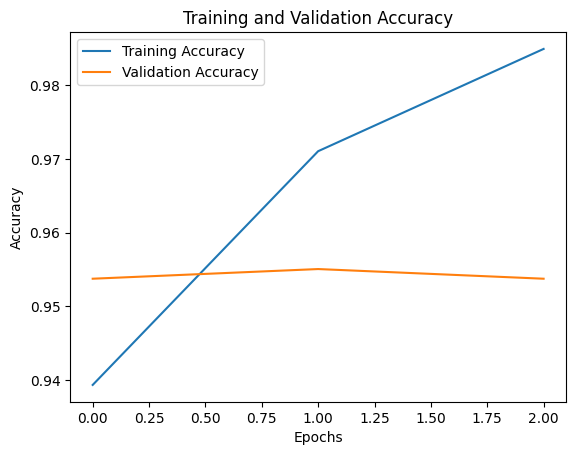

In [83]:
# plot accuracy on training and validation data
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

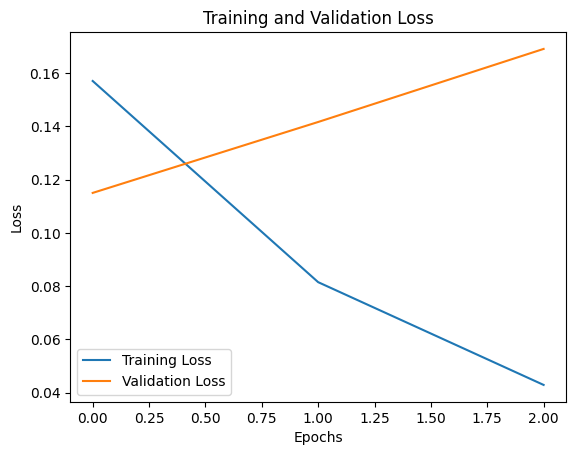

In [84]:
# plot loss on training and validation data
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [85]:
# evaluate the model on the validation set
print("\nValidation Results:")
val_predictions = model.predict(val_yelp)
predicted_labels = np.argmax(val_predictions.logits, axis=1)
true_labels = np.concatenate([y.numpy() for _, y in val_yelp], axis=0)
print(classification_report(true_labels, predicted_labels))


Validation Results:
2101/2101 [==============================] - 115s 54ms/step
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      8402
           1       0.96      0.95      0.95      8401

    accuracy                           0.95     16803
   macro avg       0.95      0.95      0.95     16803
weighted avg       0.95      0.95      0.95     16803



## 3.6. Searching for Best Model Parameters

In [28]:
model_yelp_1, history_yelp_1 = train_bert.fine_tune_bert(train_yelp_df, val_yelp_df, model_name='distilbert-base-uncased', epochs=4, max_length=256, batch_size=8, learning_rate=1e-5)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['activation_13', 'vocab_projector', 'vocab_transform', 'vocab_layer_norm']
- This IS expected if you are initializing TFDistilBertForSequenceClassification f

Epoch 1/4
9800/9800 [==============================] - 2972s 303ms/step - loss: 0.1568 - accuracy: 0.9393 - val_loss: 0.1189 - val_accuracy: 0.9529
Epoch 2/4
9800/9800 [==============================] - 2931s 299ms/step - loss: 0.0833 - accuracy: 0.9698 - val_loss: 0.1266 - val_accuracy: 0.9554
Epoch 3/4
9800/9800 [==============================] - 2777s 283ms/step - loss: 0.0440 - accuracy: 0.9850 - val_loss: 0.1611 - val_accuracy: 0.9579

Validation Results:
2101/2101 [==============================] - 189s 89ms/step
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      8402
           1       0.95      0.96      0.95      8401

    accuracy                           0.95     16803
   macro avg       0.95      0.95      0.95     16803
weighted avg       0.95      0.95      0.95     16803



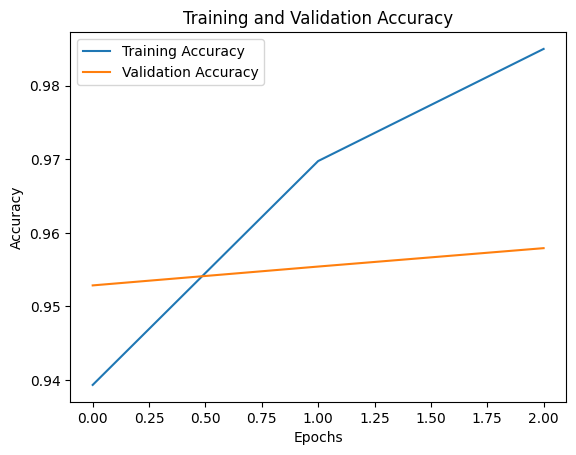

In [29]:
# plot accuracy on training and validation data
plt.plot(history_yelp_1.history['accuracy'], label='Training Accuracy')
plt.plot(history_yelp_1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

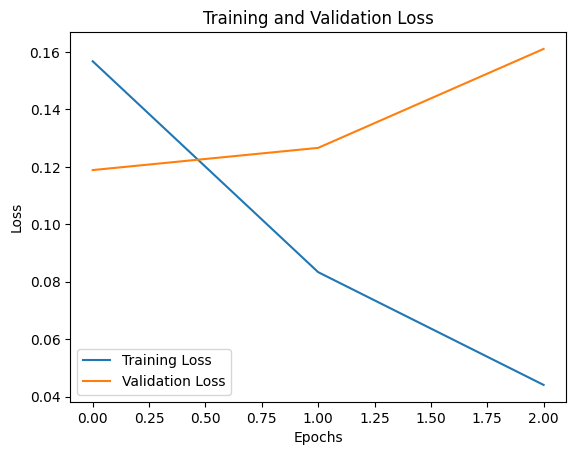

In [30]:
# plot loss on training and validation data
plt.plot(history_yelp_1.history['loss'], label='Training Loss')
plt.plot(history_yelp_1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [15]:
model_yelp_5, history_yelp_5 = train_bert.fine_tune_bert(train_yelp_df, val_yelp_df, model_name='distilbert-base-uncased', epochs=4, max_length=256, batch_size=8, learning_rate=5e-5)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['vocab_transform', 'vocab_projector', 'activation_13', 'vocab_layer_norm']
- This IS expected if you are initializing TFDistilBertForSequenceClassification f

Epoch 1/4
9800/9800 [==============================] - 1744s 177ms/step - loss: 0.1750 - accuracy: 0.9322 - val_loss: 0.1482 - val_accuracy: 0.9413
Epoch 2/4
9800/9800 [==============================] - 1741s 178ms/step - loss: 0.1083 - accuracy: 0.9604 - val_loss: 0.1486 - val_accuracy: 0.9453
Epoch 3/4
9800/9800 [==============================] - 1727s 176ms/step - loss: 0.0736 - accuracy: 0.9743 - val_loss: 0.1943 - val_accuracy: 0.9391

Validation Results:
2101/2101 [==============================] - 118s 56ms/step
              precision    recall  f1-score   support

           0       0.96      0.93      0.94      8402
           1       0.93      0.96      0.94      8401

    accuracy                           0.94     16803
   macro avg       0.94      0.94      0.94     16803
weighted avg       0.94      0.94      0.94     16803



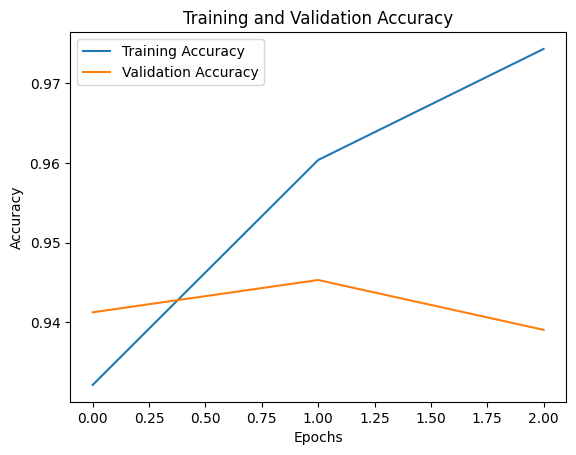

In [16]:
# plot accuracy on training and validation data
plt.plot(history_yelp_5.history['accuracy'], label='Training Accuracy')
plt.plot(history_yelp_5.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

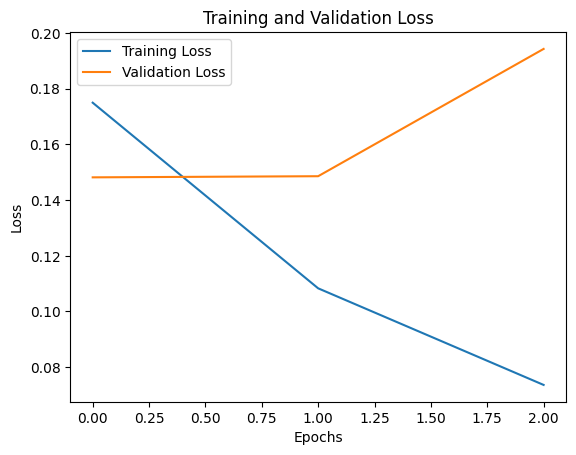

In [17]:
# plot loss on training and validation data
plt.plot(history_yelp_5.history['loss'], label='Training Loss')
plt.plot(history_yelp_5.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

## 3.7 Model Evaluation on Test Data

In [86]:
train_bert.evaluate_bert(model, test_yelp)


Evaluating on Test Set...
2100/2100 [==============================] - 113s 54ms/step
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      8400
           1       0.96      0.95      0.96      8400

    accuracy                           0.96     16800
   macro avg       0.96      0.96      0.96     16800
weighted avg       0.96      0.96      0.96     16800



## 3.8. Model Evaluation on Augmented Data

In [87]:
# load the augmented test sets
test_yelp_char_swap_file = '../data/preprocessed/yelp_test_char_swap.csv'
test_yelp_char_swap_df = pd.read_csv(test_yelp_char_swap_file, engine='python', encoding="ISO-8859-1")

test_yelp_transform_file = '../data/preprocessed/yelp_test_transform.csv'
test_yelp_transform_df = pd.read_csv(test_yelp_transform_file, engine='python', encoding="ISO-8859-1")

test_yelp_combined_file = '../data/preprocessed/yelp_test_combined.csv'
test_yelp_combined_df = pd.read_csv(test_yelp_combined_file, engine='python', encoding="ISO-8859-1")

In [88]:
test_yelp_char_swap = tokenize(
    df=test_yelp_char_swap_df, 
    model_name=model_name,
    max_length=max_length,
    batch_size=batch_size
)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [89]:
test_yelp_transform = tokenize(
    df=test_yelp_transform_df, 
    model_name=model_name,
    max_length=max_length,
    batch_size=batch_size
)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [90]:
test_yelp_combined = tokenize(
    df=test_yelp_combined_df, 
    model_name=model_name,
    max_length=max_length,
    batch_size=batch_size
)

c:\Users\Bartek\AppData\Local\pypoetry\Cache\virtualenvs\sentiment-analysis-UYCV2lRK-py3.10\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [91]:
train_bert.evaluate_bert(model, test_yelp_char_swap)


Evaluating on Test Set...
2100/2100 [==============================] - 113s 54ms/step
              precision    recall  f1-score   support

           0       0.93      0.81      0.87      8400
           1       0.83      0.94      0.88      8400

    accuracy                           0.87     16800
   macro avg       0.88      0.87      0.87     16800
weighted avg       0.88      0.87      0.87     16800



In [92]:
train_bert.evaluate_bert(model, test_yelp_transform)


Evaluating on Test Set...
2100/2100 [==============================] - 113s 54ms/step
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      8400
           1       0.94      0.92      0.93      8400

    accuracy                           0.93     16800
   macro avg       0.93      0.93      0.93     16800
weighted avg       0.93      0.93      0.93     16800



In [93]:
train_bert.evaluate_bert(model, test_yelp_combined)


Evaluating on Test Set...
2100/2100 [==============================] - 113s 54ms/step
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      8400
           1       0.79      0.91      0.85      8400

    accuracy                           0.84     16800
   macro avg       0.85      0.84      0.84     16800
weighted avg       0.85      0.84      0.84     16800



## 3.9. Save Model

In [94]:
model.save_pretrained("../outputs/models/bert/yelp_bert_model")